In [31]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from unidecode import unidecode

In [32]:
dados = pd.read_excel('WDI_EXCEL/WDIEXCEL.xlsx')

In [33]:
dados.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.488497,18.001597,18.558234,19.043572,19.586457,20.192064,20.828814,21.372164,22.100884,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.811504,7.096003,7.406706,7.666648,8.020952,8.403358,8.718306,9.097176,9.473374,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.152090,38.488233,38.779953,39.068462,39.445526,39.818645,40.276374,40.687817,41.211606,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.672943,16.527554,24.627753,25.432092,27.061929,29.154282,31.022083,32.809138,33.760782,NaN


In [34]:
dados.columns = [col.strip().replace("_", " ") for col in dados.columns]

In [35]:
print(dados.columns)


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')


In [36]:
dados_long = dados.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Value"
)

In [37]:
# Lista de indicadores de interesse para a análise
indicadores_interesse = [
    # População:
    "Population, total",
    "Population growth (annual %)",
    "Population ages 0-14 (% of total population)",
    "Population ages 15-64 (% of total population)",
    "Population ages 65 and above (% of total population)",
    
    # Demográficos:
    "Fertility rate, total (births per woman)",
    "Mortality rate, infant (per 1.000 live births)",
    "Life expectancy at birth, total (years)",
    "Net migration",
    "Birth rate, crude (per 1.000 people)",

    # Econômicos:
    "GDP per capita (current US$)",
    "GDP growth (annual %)",
    "Unemployment, total (% of total labor force)",
    "Domestic credit to private sector (% of GDP)",
    "GDP (current US$)",
    "Gross domestic savings (% of GDP)",

    # Urbanização:
    "Urban population (% of total population)",
    "Urban population growth (annual %)",
    "Population in largest city",
    "Urban land area (% of total land area)",
    "Population density (people per sq. km of land area)",
    "Rural population (% of total population)",

    # Educação:
    "School enrollment, primary (% net)",
    "Literacy rate, adult total (% of people ages 15 and above)",

    # Saúde:
    "Health expenditure, total (% of GDP)",
    "Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)",
    "Condom use, population ages 15-24, female (% of females ages 15-24)",
    "Condom use, population ages 15-24, male (% of males ages 15-24)",
    "Mortality rate, under-5 (per 1,000 live births)",
    "Prevalence of current tobacco use (% of adults)",
    "Prevalence of HIV, total (% of population ages 15-49)",
    "Pregnant women receiving prenatal care (%)",
    "People using at least basic sanitation services (% of population)",
    "Access to electricity (% of population)",
    "Internet usage (% of population)",
    "Intentional homicides (per 100,000 people)",

    # Pobreza:
    "Income share held by highest 10%",
    "Income share held by highest 20%",
    "Income share held by lowest 10%",
    "Income share held by lowest 20%",
    "Gini index",
]


# Filtrar o DataFrame para manter apenas os indicadores de interesse
dados_filtrados = dados_long[dados_long["Indicator Name"].isin(indicadores_interesse)]

# Exibir as primeiras linhas para verificação
dados_filtrados.head()


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
221,Africa Eastern and Southern,AFE,"Condom use, population ages 15-24, female (% o...",SH.CON.1524.FE.ZS,1960,NaN
222,Africa Eastern and Southern,AFE,"Condom use, population ages 15-24, male (% of ...",SH.CON.1524.MA.ZS,1960,NaN
311,Africa Eastern and Southern,AFE,Domestic credit to private sector (% of GDP),FS.AST.PRVT.GD.ZS,1960,NaN
422,Africa Eastern and Southern,AFE,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1960,6.723226


In [38]:
dados_filtrados.dtypes

Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
Year               object
Value             float64
dtype: object

In [39]:
dados_filtrados['Year'] = dados_filtrados['Year'].astype(int)

C:\Users\lucas\AppData\Local\Temp\ipykernel_24980\1717216604.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_filtrados['Year'] = dados_filtrados['Year'].astype(int)


In [40]:
print(dados_filtrados.dtypes)

Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
Year                int32
Value             float64
dtype: object


In [41]:
x = dados_filtrados['Country Name'].nunique()
print(x)

266


In [42]:
paises_unicos = dados_filtrados["Country Name"].unique()
print(paises_unicos)

['Africa Eastern and Southern' 'Africa Western and Central' 'Arab World'
 'Caribbean small states' 'Central Europe and the Baltics'
 'Early-demographic dividend' 'East Asia & Pacific'
 'East Asia & Pacific (excluding high income)'
 'East Asia & Pacific (IDA & IBRD countries)' 'Euro area'
 'Europe & Central Asia' 'Europe & Central Asia (excluding high income)'
 'Europe & Central Asia (IDA & IBRD countries)' 'European Union'
 'Fragile and conflict affected situations'
 'Heavily indebted poor countries (HIPC)' 'High income' 'IBRD only'
 'IDA & IBRD total' 'IDA blend' 'IDA only' 'IDA total'
 'Late-demographic dividend' 'Latin America & Caribbean'
 'Latin America & Caribbean (excluding high income)'
 'Latin America & the Caribbean (IDA & IBRD countries)'
 'Least developed countries: UN classification' 'Low & middle income'
 'Low income' 'Lower middle income' 'Middle East & North Africa'
 'Middle East & North Africa (excluding high income)'
 'Middle East & North Africa (IDA & IBRD countries)

In [43]:
#dados_filtrados.loc[:, "Value"] = dados_filtrados["Value"].fillna(0)
#dados_filtrados.head()

In [44]:
sub_dfs_por_pais = {pais: grupo for pais, grupo in dados_filtrados.groupby("Country Name")}
Argentina = sub_dfs_por_pais["Argentina"]
Argentina.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
83779,Argentina,ARG,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
83997,Argentina,ARG,"Condom use, population ages 15-24, female (% o...",SH.CON.1524.FE.ZS,1960,NaN
83998,Argentina,ARG,"Condom use, population ages 15-24, male (% of ...",SH.CON.1524.MA.ZS,1960,NaN
84087,Argentina,ARG,Domestic credit to private sector (% of GDP),FS.AST.PRVT.GD.ZS,1960,13.611244
84198,Argentina,ARG,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1960,3.075000


In [45]:
for pais in sub_dfs_por_pais:
    sub_dfs_por_pais[pais].drop(columns=["Country Code", "Country Name"], inplace=True)
    sub_dfs_por_pais[pais].reset_index(drop=True, inplace=True)

In [46]:
brasil = sub_dfs_por_pais["Brazil"]
brasil.head()

,Indicator Name,Indicator Code,Year,Value
0,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
1,"Condom use, population ages 15-24, female (% o...",SH.CON.1524.FE.ZS,1960,NaN
2,"Condom use, population ages 15-24, male (% of ...",SH.CON.1524.MA.ZS,1960,NaN
3,Domestic credit to private sector (% of GDP),FS.AST.PRVT.GD.ZS,1960,17.972727
4,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1960,6.061000


In [47]:
pop_brasil = brasil[brasil['Indicator Name'] == 'Population, total']
pop_brasil = pop_brasil[['Year', 'Value']].copy()  # Mantém só colunas de interesse
pop_brasil.head()


,Year,Value
26,1960,72388126.0
61,1961,74605447.0
96,1962,76865323.0
131,1963,79164235.0
166,1964,81488595.0


In [48]:
# 1. Filtrar apenas as colunas importantes para a pivotagem
df_brasil = brasil[["Year", "Indicator Name", "Value"]].copy()

# 2. Pivotar para ficar no formato "wide" (uma coluna por indicador)
df_brasil_wide = df_brasil.pivot(
    index="Year",
    columns="Indicator Name",
    values="Value"
)

# 3. Ordenar pelas datas (anos) e exibir as primeiras linhas
df_brasil_wide.sort_index(inplace=True)
df_brasil_wide.head()

Indicator Name,Access to electricity (% of population),"Condom use, population ages 15-24, female (% of females ages 15-24)","Condom use, population ages 15-24, male (% of males ages 15-24)",Domestic credit to private sector (% of GDP),"Fertility rate, total (births per woman)",GDP (current US$),GDP growth (annual %),GDP per capita (current US$),Gini index,Gross domestic savings (% of GDP),...,Population in largest city,"Population, total",Pregnant women receiving prenatal care (%),"Prevalence of HIV, total (% of population ages 15-49)",Prevalence of current tobacco use (% of adults),Rural population (% of total population),"School enrollment, primary (% net)","Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)",Urban population (% of total population),Urban population growth (annual %)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,17.972727,6.061,1.703047e+10,NaN,235.266010,NaN,28.421716,...,4493182.0,72388126.0,NaN,NaN,NaN,53.861,NaN,NaN,46.139,NaN
1961,NaN,NaN,NaN,17.022008,6.044,1.727594e+10,8.6,231.564063,NaN,30.585540,...,4681086.0,74605447.0,NaN,NaN,NaN,52.878,NaN,NaN,47.122,5.125267
1962,NaN,NaN,NaN,17.028529,5.995,1.923175e+10,6.6,250.200573,NaN,15.333329,...,4878624.0,76865323.0,NaN,NaN,NaN,51.901,NaN,NaN,48.099,5.036272
1963,NaN,NaN,NaN,14.705662,5.929,2.328771e+10,0.6,294.169619,NaN,20.109254,...,5084497.0,79164235.0,NaN,NaN,NaN,50.922,NaN,NaN,49.078,4.961925
1964,NaN,NaN,NaN,13.523514,5.818,2.096373e+10,3.4,257.259727,NaN,18.355038,...,5299360.0,81488595.0,NaN,NaN,NaN,49.941,NaN,NaN,50.059,4.872991


In [49]:
df_brasil_wide.describe()


Indicator Name,Access to electricity (% of population),"Condom use, population ages 15-24, female (% of females ages 15-24)","Condom use, population ages 15-24, male (% of males ages 15-24)",Domestic credit to private sector (% of GDP),"Fertility rate, total (births per woman)",GDP (current US$),GDP growth (annual %),GDP per capita (current US$),Gini index,Gross domestic savings (% of GDP),...,Population in largest city,"Population, total",Pregnant women receiving prenatal care (%),"Prevalence of HIV, total (% of population ages 15-49)",Prevalence of current tobacco use (% of adults),Rural population (% of total population),"School enrollment, primary (% net)","Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)",Urban population (% of total population),Urban population growth (annual %)
count,33.000000,1.0,1.0,62.000000,63.000000,6.400000e+01,63.000000,64.000000,38.000000,64.000000,...,6.400000e+01,6.400000e+01,9.000000,33.000000,7.000000,64.000000,16.000000,21.000000,64.000000,63.000000
mean,96.405326,17.8,50.8,47.377874,3.263397,7.615755e+11,3.861055,4151.918500,56.284211,19.788101,...,1.437838e+07,1.487278e+08,93.788889,0.390909,16.528571,28.018391,95.374672,8.307143,71.981609,2.720236
std,3.694988,NaN,NaN,24.528847,1.439829,8.028645e+11,4.070067,3847.072417,3.337625,3.696935,...,5.481314e+06,4.395877e+07,7.952114,0.133144,4.229545,12.931267,1.755277,0.346730,12.931267,1.371139
min,87.475116,17.8,50.8,11.896988,1.626000,1.703047e+10,-4.350000,231.564063,48.900000,12.727742,...,4.493182e+06,7.238813e+07,74.000000,0.200000,12.800000,12.212000,91.589060,7.670000,46.139000,0.632380
25%,94.193812,17.8,50.8,30.093198,1.904000,1.471776e+11,1.180803,1342.451702,53.400000,17.221346,...,9.952486e+06,1.095649e+08,96.700000,0.300000,13.200000,16.476750,94.653747,8.200000,61.506000,1.348287
50%,97.600000,17.8,50.8,44.925375,2.815000,3.906414e+11,3.530000,2583.937628,56.400000,20.042109,...,1.517836e+07,1.529997e+08,97.200000,0.400000,14.900000,24.933000,95.239410,8.360000,75.067000,2.671691
75%,99.600000,17.8,50.8,60.034838,4.377000,1.416863e+12,6.334935,7158.068164,58.975000,21.442558,...,1.889359e+07,1.890061e+08,97.400000,0.500000,18.900000,38.494000,96.452938,8.570000,83.523250,3.922914
max,100.000000,17.8,50.8,134.113589,6.061000,2.616156e+12,13.968722,13396.624357,63.200000,30.585540,...,2.261974e+07,2.111407e+08,98.200000,0.600000,23.800000,53.861000,98.075500,8.710000,87.788000,5.125267


In [50]:
df_brasil_wide.isna().sum()


Indicator Name
Access to electricity (% of population)                                                                 31
Condom use, population ages 15-24, female (% of females ages 15-24)                                     63
Condom use, population ages 15-24, male (% of males ages 15-24)                                         63
Domestic credit to private sector (% of GDP)                                                             2
Fertility rate, total (births per woman)                                                                 1
GDP (current US$)                                                                                        0
GDP growth (annual %)                                                                                    1
GDP per capita (current US$)                                                                             0
Gini index                                                                                              26
Gross domestic savings

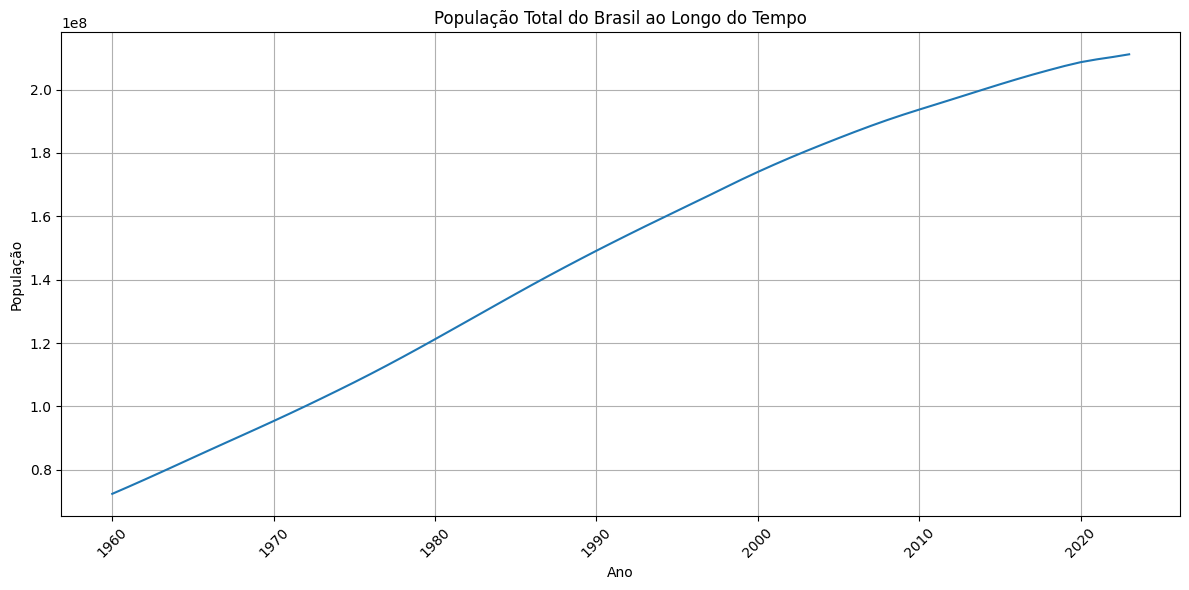

In [56]:
# Visualizar a tendência histórica da população total
plt.figure(figsize=(12, 6))
pop_brasil = brasil[brasil['Indicator Name'] == 'Population, total']
sns.lineplot(data=pop_brasil, x='Year', y='Value')
plt.title('População Total do Brasil ao Longo do Tempo')
plt.ylabel('População')
plt.xlabel('Ano')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

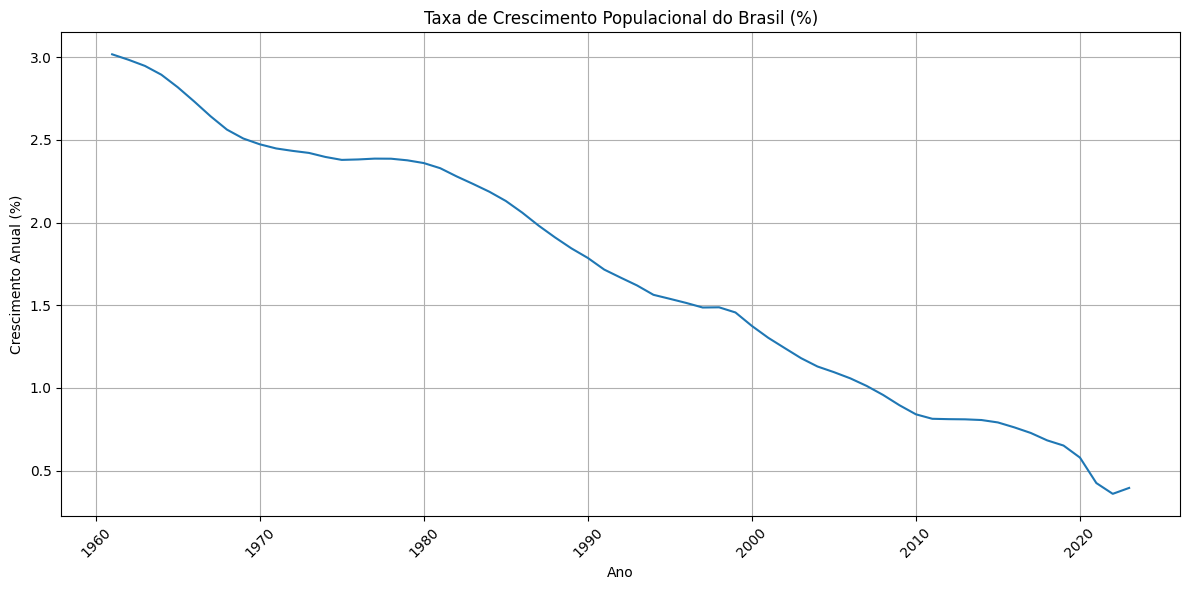

In [57]:
# Visualizar taxas de crescimento populacional
crescimento_pop = brasil[brasil['Indicator Name'] == 'Population growth (annual %)']
plt.figure(figsize=(12, 6))
sns.lineplot(data=crescimento_pop, x='Year', y='Value')
plt.title('Taxa de Crescimento Populacional do Brasil (%)')
plt.ylabel('Crescimento Anual (%)')
plt.xlabel('Ano')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


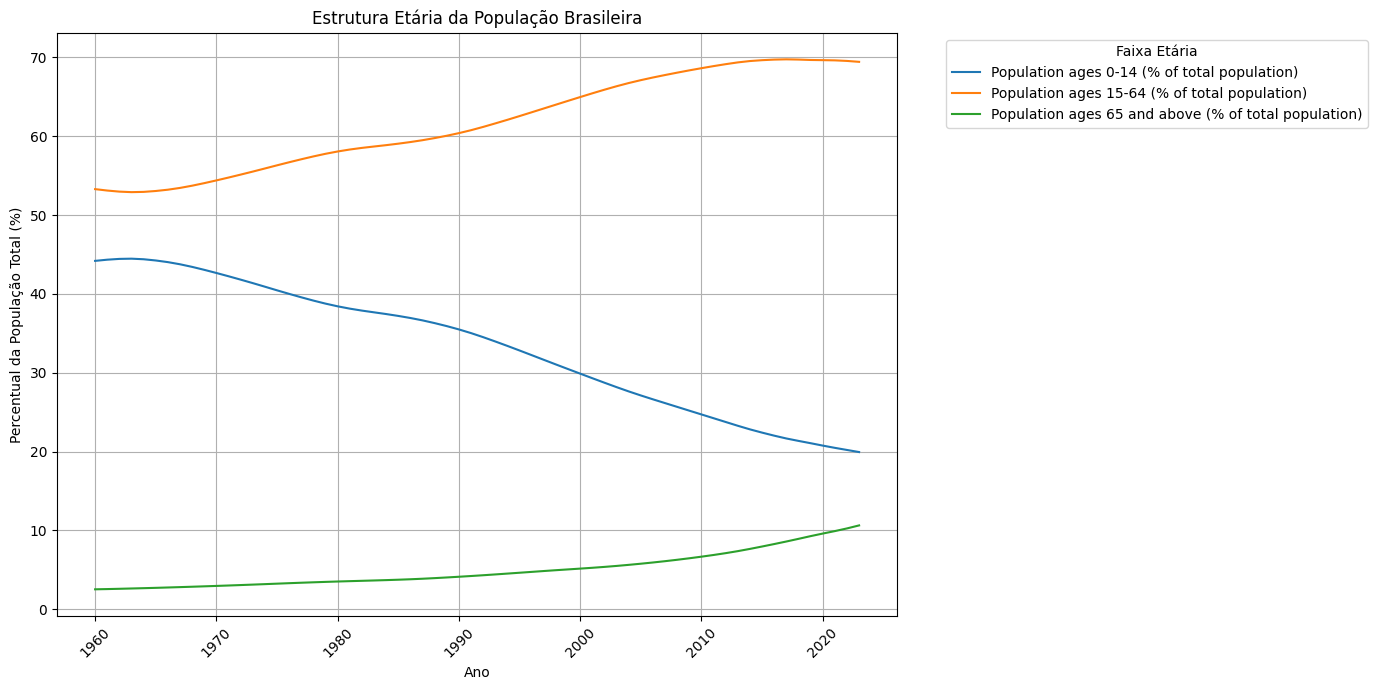

In [58]:
# Análise da estrutura etária ao longo do tempo
faixas_etarias = [
    'Population ages 0-14 (% of total population)',
    'Population ages 15-64 (% of total population)',
    'Population ages 65 and above (% of total population)'
]

estrutura_etaria = brasil[brasil['Indicator Name'].isin(faixas_etarias)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=estrutura_etaria, x='Year', y='Value', hue='Indicator Name')
plt.title('Estrutura Etária da População Brasileira')
plt.ylabel('Percentual da População Total (%)')
plt.xlabel('Ano')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Faixa Etária', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [59]:
# Análise de fatores demográficos que afetam a população
fatores_demograficos = [
    'Fertility rate, total (births per woman)',
    'Mortality rate, infant (per 1.000 live births)',
    'Life expectancy at birth, total (years)',
    'Birth rate, crude (per 1.000 people)'
]

# Normalizando os dados para visualização conjunta
dados_demograficos = brasil[brasil['Indicator Name'].isin(fatores_demograficos)].copy()

# Pivot para ter cada indicador como coluna
dados_pivot = dados_demograficos.pivot(index='Year', columns='Indicator Name', values='Value')

# Normalização min-max para cada coluna
dados_norm = (dados_pivot - dados_pivot.min()) / (dados_pivot.max() - dados_pivot.min())


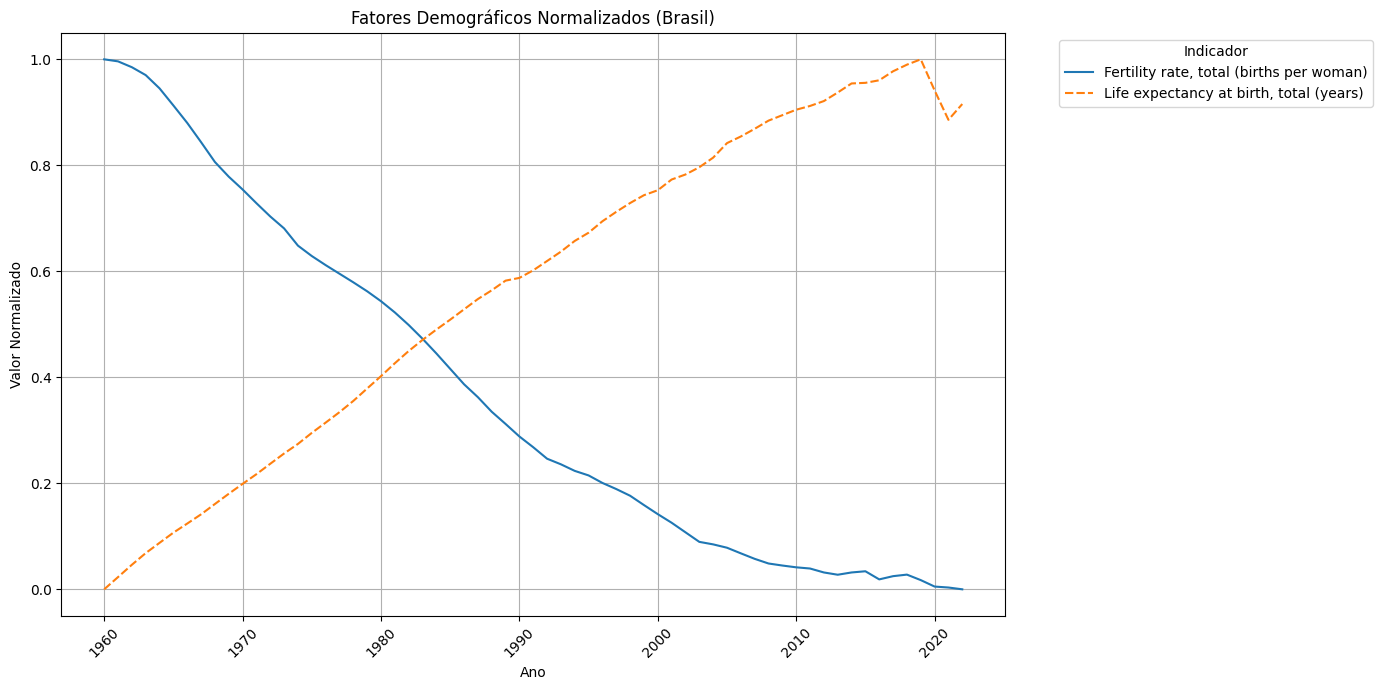

In [60]:
# Plotando dados normalizados
plt.figure(figsize=(14, 7))
sns.lineplot(data=dados_norm)
plt.title('Fatores Demográficos Normalizados (Brasil)')
plt.ylabel('Valor Normalizado')
plt.xlabel('Ano')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Indicador', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

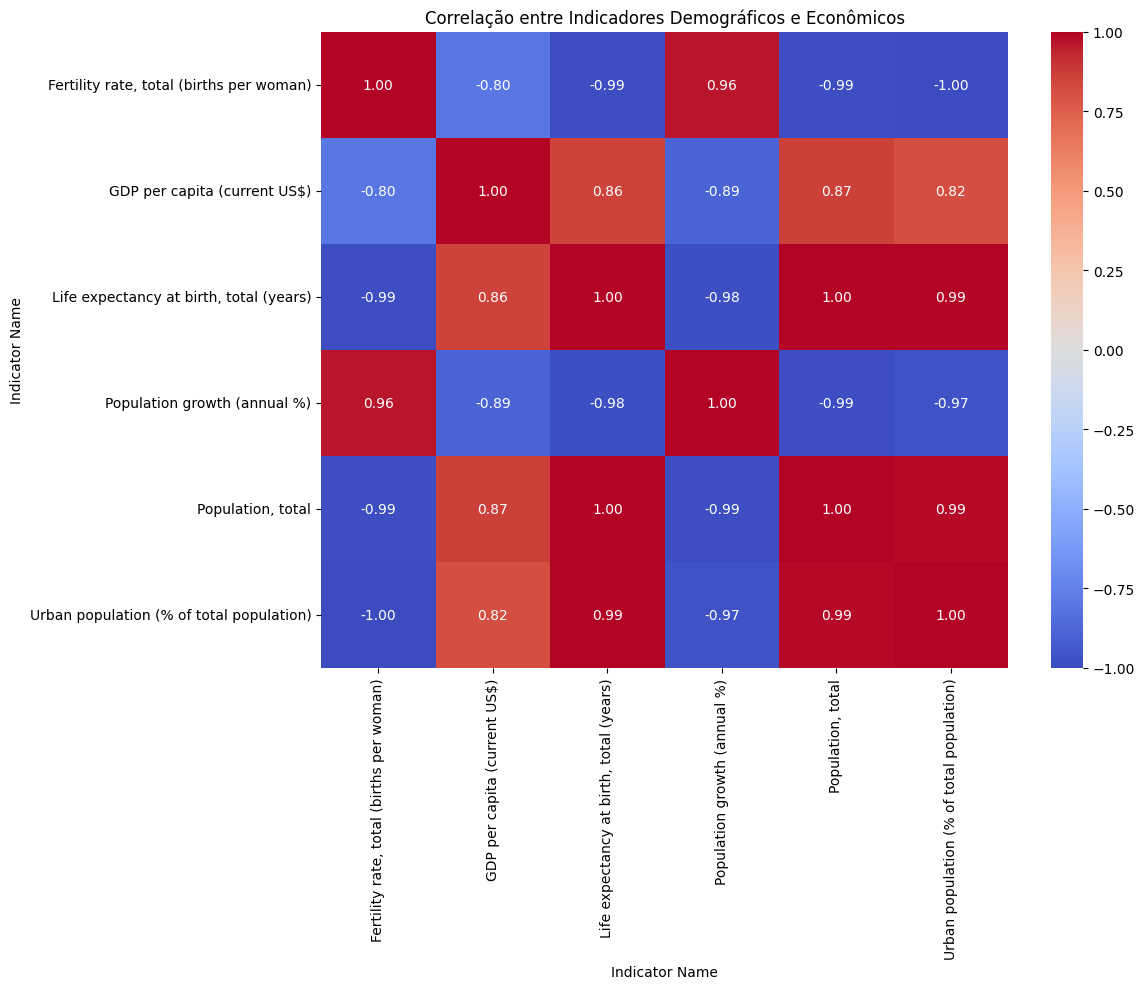

In [62]:
# Análise de correlação entre fatores demográficos e econômicos
indicadores_correlacao = [
    'Population, total',
    'Population growth (annual %)',
    'GDP per capita (current US$)',
    'Urban population (% of total population)',
    'Life expectancy at birth, total (years)',
    'Fertility rate, total (births per woman)'
]

# Filtrar apenas os indicadores selecionados
dados_corr = brasil[brasil['Indicator Name'].isin(indicadores_correlacao)]

# Pivotar para formato amplo
dados_corr_wide = dados_corr.pivot(index='Year', columns='Indicator Name', values='Value')

# Calcular correlação
matriz_corr = dados_corr_wide.corr()

# Plotar mapa de calor de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlação entre Indicadores Demográficos e Econômicos')
plt.tight_layout()
plt.show()